In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, mstats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# Load the data
file_path = 'Time_for_Bac_Fix_Pos50_Start.xlsx'
df = pd.read_excel(file_path)
df

,Normal Model,No Conj,No R_a with Conj,No R_a No Conj
0,3124,3396,4878,9325
1,6104,6099,4917,7508
2,3418,3482,2355,3453
3,4620,4762,3168,3480
4,4282,4366,2845,3649
...,...,...,...,...
95,5321,5334,3265,7081
96,1952,3473,1465,7508
97,5412,9228,5837,7013
98,4658,4889,2638,4643


In [14]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Model'] = remove_outliers(df, 'Normal Model')['Normal Model']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']

# Drop NaN values from each column individually
df_cleaned['Normal Model'] = df_cleaned['Normal Model'].dropna()
df_cleaned['No Conj'] = df_cleaned['No Conj'].dropna()
df_cleaned['No R_a with Conj'] = df_cleaned['No R_a with Conj'].dropna()
df_cleaned['No R_a No Conj'] = df_cleaned['No R_a No Conj'].dropna()

# Reset the indices to ensure alignment
df_cleaned = df_cleaned.reset_index(drop=True)

# Describe the cleaned DataFrame
df_cleaned.describe()

,Normal Model,No Conj,No R_a with Conj,No R_a No Conj
count,95.000000,95.000000,99.000000,100.000000
mean,4401.042105,5135.263158,3553.484848,5243.070000
std,1721.720669,1813.841610,1384.926870,2030.393072
min,1657.000000,1656.000000,1358.000000,1974.000000
25%,3165.500000,3749.500000,2468.000000,3501.750000
50%,4316.000000,4918.000000,3323.000000,4938.000000
75%,5467.500000,6253.500000,4394.000000,6902.250000
max,9341.000000,9823.000000,7163.000000,9820.000000


In [15]:
# Reshape the DataFrame using pd.melt
df_melted = pd.melt(df_cleaned, var_name='Condition', value_name='Time')

# Create boolean columns for each condition
df_melted['Normal Model'] = df_melted['Condition'] == 'Normal Model'
df_melted['No Conj'] = df_melted['Condition'] == 'No Conj'
df_melted['No R_a with Conj'] = df_melted['Condition'] == 'No R_a with Conj'
df_melted['No R_a No Conj'] = df_melted['Condition'] == 'No R_a No Conj'

# Drop the original 'Condition' column as it's no longer needed
df_final = df_melted.drop('Condition', axis=1)

# Display the reshaped DataFrame
print(df_final)

       Time  Normal Model  No Conj  No R_a with Conj  No R_a No Conj
0    3124.0          True    False             False           False
1    6104.0          True    False             False           False
2    3418.0          True    False             False           False
3    4620.0          True    False             False           False
4    4282.0          True    False             False           False
..      ...           ...      ...               ...             ...
395  7081.0         False    False             False            True
396  7508.0         False    False             False            True
397  7013.0         False    False             False            True
398  4643.0         False    False             False            True
399  5652.0         False    False             False            True

[400 rows x 5 columns]


In [16]:
# Remove NaN values from each column independently and concatenate them into a single DataFrame
normal_equation_cleaned = df_cleaned['Normal Model'].dropna().reset_index(drop=True)
no_conj_cleaned = df_cleaned['No Conj'].dropna().reset_index(drop=True)
no_ra_with_conj_cleaned = df_cleaned['No R_a with Conj'].dropna().reset_index(drop=True)
no_ra_no_conj_cleaned = df_cleaned['No R_a No Conj'].dropna().reset_index(drop=True)

# Concatenate the cleaned columns into a single DataFrame
df_cleaned_combined = pd.concat([normal_equation_cleaned, no_conj_cleaned, no_ra_with_conj_cleaned, no_ra_no_conj_cleaned], axis=1)
df_cleaned_combined.columns = ['Normal Model', 'No Conj', 'No R_a with Conj', 'No R_a No Conj']

# Reshape the DataFrame using pd.melt
df_melted = pd.melt(df_cleaned_combined, var_name='Condition', value_name='Time')

# Remove NaN values from the melted DataFrame
df_melted = df_melted.dropna(subset=['Time'])

# Create boolean columns for Conjugation and R_a based on the conditions described
df_melted['Conjugation'] = df_melted['Condition'].apply(lambda x: x in ['Normal Model', 'No R_a with Conj'])
df_melted['R_a'] = df_melted['Condition'].apply(lambda x: x in ['Normal Model', 'No Conj'])

# Display the reshaped DataFrame
df_melted = df_melted.reset_index(drop=True)
df_melted

,Condition,Time,Conjugation,R_a
0,Normal Model,3124.0,True,True
1,Normal Model,6104.0,True,True
2,Normal Model,3418.0,True,True
3,Normal Model,4620.0,True,True
4,Normal Model,4282.0,True,True
...,...,...,...,...
384,No R_a No Conj,7081.0,False,False
385,No R_a No Conj,7508.0,False,False
386,No R_a No Conj,7013.0,False,False
387,No R_a No Conj,4643.0,False,False


In [17]:
# The df_melted DataFrame contains the columns 'Condition', 'Time', 'Conjugation', and 'R_a'

# Define groups for comparison based on df_melted
group_normal = df_melted[(df_melted['Conjugation'] == True) & (df_melted['R_a'] == True)]['Time']
group_no_conj = df_melted[(df_melted['Conjugation'] == False) & (df_melted['R_a'] == True)]['Time']
group_no_ra_with_conj = df_melted[(df_melted['Conjugation'] == True) & (df_melted['R_a'] == False)]['Time']
group_no_ra_no_conj = df_melted[(df_melted['Conjugation'] == False) & (df_melted['R_a'] == False)]['Time']

# Perform Mann-Whitney U tests and calculate effect sizes
def compare_groups(group1, group2):
    u_stat, p_value = mannwhitneyu(group1, group2)
    effect_size = (u_stat - (len(group1) * len(group2) / 2)) / np.sqrt(len(group1) * len(group2) * (len(group1) + len(group2) + 1) / 12)
    return u_stat, p_value, effect_size

results = {
    'Normal vs No Conj': compare_groups(group_normal, group_no_conj),
    'Normal vs No R_a with Conj': compare_groups(group_normal, group_no_ra_with_conj),
    'Normal vs No R_a No Conj': compare_groups(group_normal, group_no_ra_no_conj)
}

# Print results
for comparison, (u_stat, p_value, effect_size) in results.items():
    print(f"{comparison}: U-statistic = {u_stat}, P-value = {p_value}, Effect Size = {effect_size}")

Normal vs No Conj: U-statistic = 3383.5, P-value = 0.0029060017424076515, Effect Size = -2.9788201026946033
Normal vs No R_a with Conj: U-statistic = 6055.5, P-value = 0.0005408877996398454, Effect Size = 3.4609212225218338
Normal vs No R_a No Conj: U-statistic = 3654.0, P-value = 0.005417797009978717, Effect Size = -2.782347300102708


In [9]:
mean_values = df_melted.groupby(['Conjugation', 'R_a'])['Time'].median()
mean_values

Conjugation  R_a  
False        False    4938.0
             True     4918.0
True         False    3323.0
             True     4316.0
Name: Time, dtype: float64

In [10]:
# Define a function to calculate the interaction effect
def interaction_effect(df, column):
    mean_values = df.groupby(['Conjugation', 'R_a'])[column].mean()
    # interaction = (Difference when Conjugation is present) - (Difference when Conjugation is absent)
    interaction = (mean_values[True, True] - mean_values[True, False]) - (mean_values[False, True] - mean_values[False, False])
    return interaction

# Calculate observed interaction effect
observed_interaction = interaction_effect(df_melted, 'Time')

# Permutation test to randomly shuffle the data.
n_permutations = 10000
interaction_effects = []
for _ in range(n_permutations):
    permuted_df = df_melted.copy()
    # The permutation test works by assuming that under the null hypothesis, there is no relationship between the dependent and independent variables. 
    # By permuting the dependent variable, we simulate what the data would look like if this null hypothesis were true.
    permuted_df['Time'] = np.random.permutation(permuted_df['Time'])
    interaction = interaction_effect(permuted_df, 'Time')
    interaction_effects.append(interaction)

# Calculate p-value
interaction_effects = np.array(interaction_effects)
# Determine the proportion of permuted statistics that are as extreme or more extreme than the observed statistic. 
# This proportion is the p-value, representing the probability of observing such an extreme statistic under the null hypothesis.
p_value_perm = np.mean(np.abs(interaction_effects) >= np.abs(observed_interaction))
print(f"Observed Interaction Effect: {observed_interaction}")
print(f"P-value from Permutation Test: {p_value_perm}")

Observed Interaction Effect: 955.3640988835728
P-value from Permutation Test: 0.0125


C:\Users\Mike\AppData\Local\Temp\ipykernel_4640\667960159.py:29: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='R_a', y='median', hue='Conjugation', data=df_agg_reset, dodge=True, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind', ax=ax)


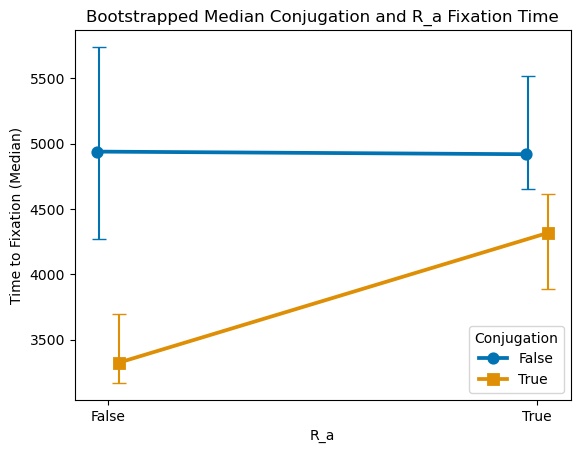

In [11]:
# Custom function to compute median and bootstrapped confidence intervals
def bootstrapped_median_with_confidence(data):
    median = np.median(data)
    # Bootstrapped confidence intervals
    # creates 1000 bootstrap samples from the input data, each of the same length as the original data.
    bootstrapped_samples = np.random.choice(data, (1000, len(data)), replace=True)
    # median of each bootstrap sample.
    bootstrapped_medians = np.median(bootstrapped_samples, axis=1)
    # calculates the 2.5th percentile of the bootstrap medians, representing the lower bound of the 95% confidence interval.
    ci_lower = np.percentile(bootstrapped_medians, 2.5)
    # calculates the 97.5th percentile of the bootstrap medians, representing the upper bound of the 95% confidence interval.
    ci_upper = np.percentile(bootstrapped_medians, 97.5)
    return pd.Series([median, ci_lower, ci_upper], index=['median', 'ci_lower', 'ci_upper'])

def median_with_confidence(data):
    median = np.median(data)
    # Calculate confidence intervals directly from the data using the mstats.mquantiles method
    ci_lower, ci_upper = mstats.mquantiles(data, prob=[0.025, 0.975])
    return pd.Series([median, ci_lower, ci_upper], index=['median', 'ci_lower', 'ci_upper'])

# Apply custom aggregation function
df_agg = df_melted.groupby(['Conjugation', 'R_a'])['Time'].apply(bootstrapped_median_with_confidence).unstack()

# Prepare data for plotting
df_agg_reset = df_agg.reset_index()

# Plot the interaction plot
fig, ax = plt.subplots()
sns.pointplot(x='R_a', y='median', hue='Conjugation', data=df_agg_reset, dodge=True, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind', ax=ax)
# Error Bars
# Add error bars manually
palette = sns.color_palette('colorblind')
for i, hue in enumerate(df_agg_reset['Conjugation'].unique()):
    # hue is True, False
    hue_data = df_agg_reset[df_agg_reset['Conjugation'] == hue]
    ax.errorbar(x=np.arange(len(hue_data)) - 0.022 + 0.048*i, y=hue_data['median'], # (x, y) coordinate for error bars
                yerr=[hue_data['median'] - hue_data['ci_lower'], hue_data['ci_upper'] - hue_data['median']], # Error bar length
                fmt='none', c=palette[i], capsize=5, label=f'{hue}') # palette[i] chooses colour 0 then colour 1 for each error bar.

ax.set_title('Bootstrapped Median Conjugation and R_a Fixation Time')
ax.set_ylabel('Time to Fixation (Median)')
plt.show()

C:\Users\Mike\AppData\Local\Temp\ipykernel_4640\3906469014.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  interaction_plot = sns.pointplot(x='R_a', y='Time', hue='Conjugation', data=df_melted, dodge=False, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind')


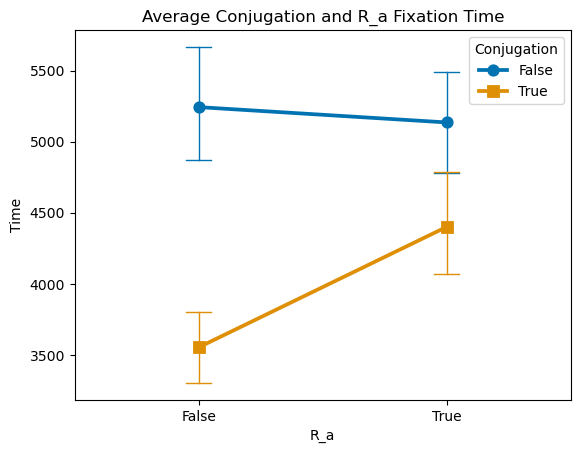

In [12]:
# Visualization: Interaction plot
interaction_plot = sns.pointplot(x='R_a', y='Time', hue='Conjugation', data=df_melted, dodge=False, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind')
interaction_plot.set_title('Average Conjugation and R_a Fixation Time')
plt.show()

Permutation Test:

    The permutation test provides a non-parametric method to assess the significance of the interaction effect between R_a and conjugation.
    An interaction = (Mean difference when Conjugation is present) - (Mean difference when Conjugation is absent) was calculated.
    This was used in a permutation test under the assumption of null hypothesis that there is no statistical difference between the means of conjugation being present.
    The observed interaction effect of -1053.13 suggests that the combined presence of Conjugation and R_a​ reduces the time to fixation.
    The p-value of 0.0712 indicates that the observed interaction effect is not statistically significant at the 5% level.
    Even thought the p-value does not meet the conventional threshold, it still shows a notable practical impact that's not highly likely to occur by chance.
    This warrants further investigation on the effect of conjugation in more advanced models.

Mann-Whitney U Test and Effect Sizes:

    Significant differences are found when comparing the Normal Model to the groups without R_a​, both with and without Conjugation, (Effect Size = -3.8324175812283574, -3.445115687473083).
    The effect sizes indicate that R_a​ has a substantial impact on the time to fixation, while the impact of Conjugation alone is moderate, (Normal vs no Conj Effect Size = -1.5431633257721498).